In [13]:
import numpy as np

#### 1.6.2 Random signals and their generation

Using the random seed is important for reproductibility purposes!

In [14]:
import numpy as np


print("1) Without setting a seed (results change):")

run1 = np.random.normal(loc=0, scale=1, size=5)
run2 = np.random.normal(loc=0, scale=1, size=5)

print("Run 1:", np.round(run1, 3))
print("Run 2:", np.round(run2, 3))
print("Are they equal?", np.allclose(run1, run2))
print("\n2) Setting a seed (results are reproducible):")

np.random.seed(2026)

run3 = np.random.normal(loc=0, scale=1, size=5)


np.random.seed(2026)

run4 = np.random.normal(loc=0, scale=1, size=5)

print("Run 3:", np.round(run3, 3))
print("Run 4:", np.round(run4, 3))
print("Are they equal?", np.allclose(run3, run4))

1) Without setting a seed (results change):
Run 1: [ 0.298 -0.83  -1.596  0.613 -0.318]
Run 2: [-0.074 -0.609 -2.     0.908  0.483]
Are they equal? False

2) Setting a seed (results are reproducible):
Run 3: [-0.432 -1.393  0.312 -0.013  1.45 ]
Run 4: [-0.432 -1.393  0.312 -0.013  1.45 ]
Are they equal? True


So, let's determine the seed and feed it to the random number generator that we
will use 

In [15]:
# Initiate a random seed for reproducibility
seed = 42

# Initiate a random number generator
rng = np.random.default_rng(seed)

How to obtain samples from a uniform distribution?

In [16]:
# Obtaining 10 samples from a uniform distribution between 0 and 1 using our
# random number generator
samples = rng.uniform(0, 1, 10)
print(samples)

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235
 0.7611397  0.78606431 0.12811363 0.45038594]


How to obtain samples from a normal (gaussian) distribution?

In [17]:
# Obtaining 10 samples from a normal distribution between 0 and 1 using our
# random number generator
samples_normal = rng.normal(0, 1, 10)
print(samples_normal)

[ 0.87939797  0.77779194  0.0660307   1.12724121  0.46750934 -0.85929246
  0.36875078 -0.9588826   0.8784503  -0.04992591]


Quick demonstration about the Central Limit Theorem, which states that the sampling distribution of the sample mean approaches a normal distribution as the sample size increases, regardless of the population's underlying distribution shape.

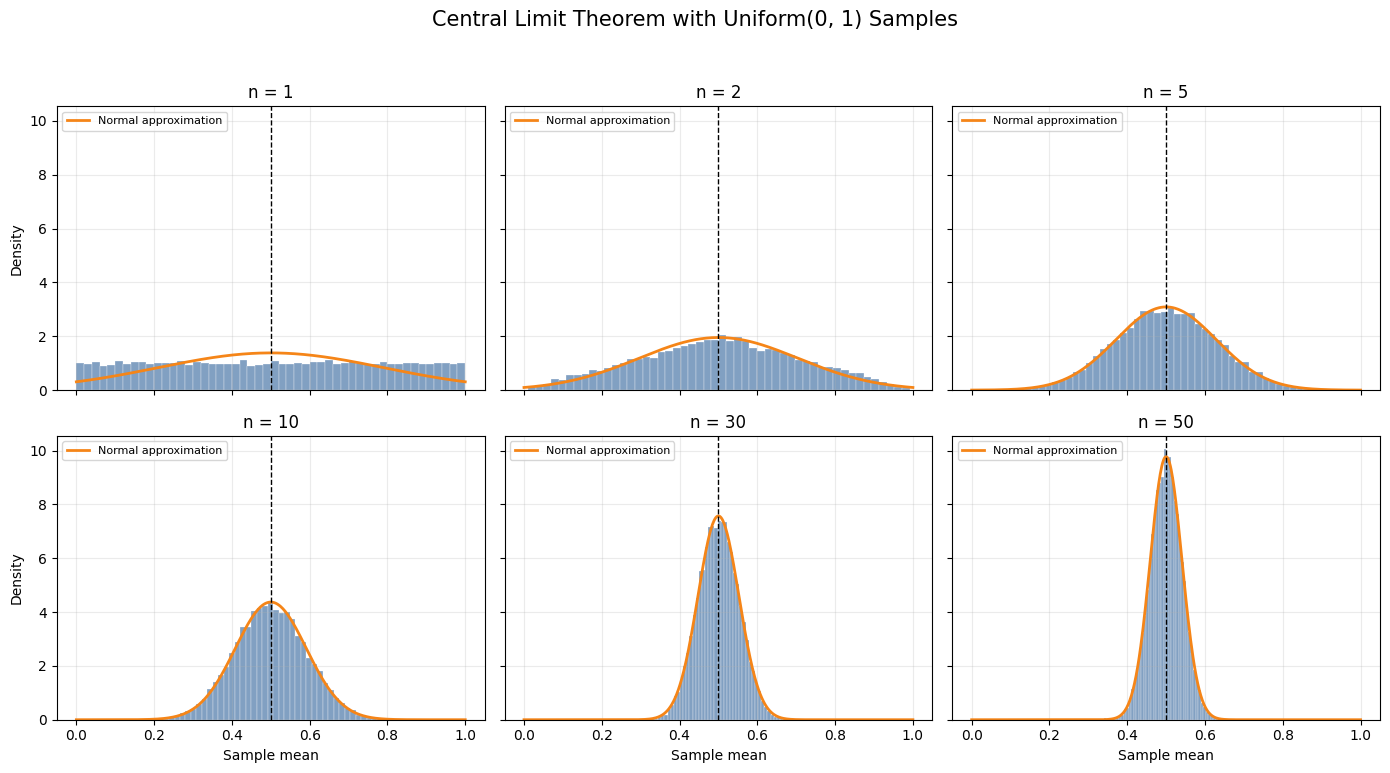

In [18]:
import matplotlib.pyplot as plt


# Remember to set the seed for reproducibility!
seed_clt = 42
rng_clt = np.random.default_rng(seed_clt)

n_values = [1, 2, 5, 10, 30, 50]  # Sample sizes
num_trials = 20_000  # Number of experiments per sample size
mu = 0.5  # Mean of Uniform(0, 1)
x = np.linspace(0, 1, 500)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, n in zip(axes, n_values):
    sample_means = rng_clt.uniform(0, 1, size=(num_trials, n)).mean(axis=1)
    ax.hist(
        sample_means,
        bins=50,
        density=True,
        alpha=0.7,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.3,
    )

    # Normal approximation predicted by the Central Limit Theorem
    sigma = np.sqrt((1 / 12) / n)
    normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )
    ax.plot(x, normal_pdf, color="#F58518", linewidth=2, label="Normal approximation")
    ax.axvline(mu, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"n = {n}")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

for ax in axes[3:]:
    ax.set_xlabel("Sample mean")

for idx in [0, 3]:
    axes[idx].set_ylabel("Density")


fig.suptitle("Central Limit Theorem with Uniform(0, 1) Samples", fontsize=15)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])

plt.show()

#### 1.6.4 Power and energy signals

Example of an energy signal

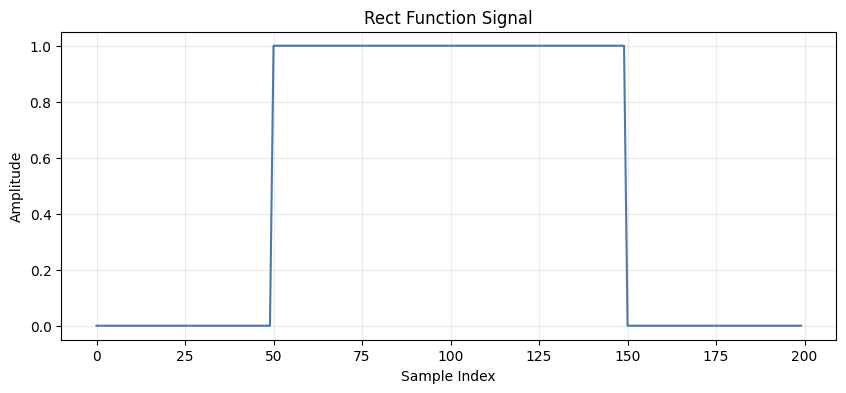

Average power of the pulse signal over an infinite time interval: 0.0


In [35]:
# Pulse signal
rect_signal = np.concatenate((np.zeros(50), np.ones(100), np.zeros(50)))

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(rect_signal, color="#4C78A8")
plt.title("Rect Function Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.show()

# Calculate the average power of this signal over an infinite time interval
average_power = np.mean(rect_signal**2)/np.inf
print(f"Average power of the pulse signal over an infinite time interval: {average_power:.1f}")


Example of an power signal

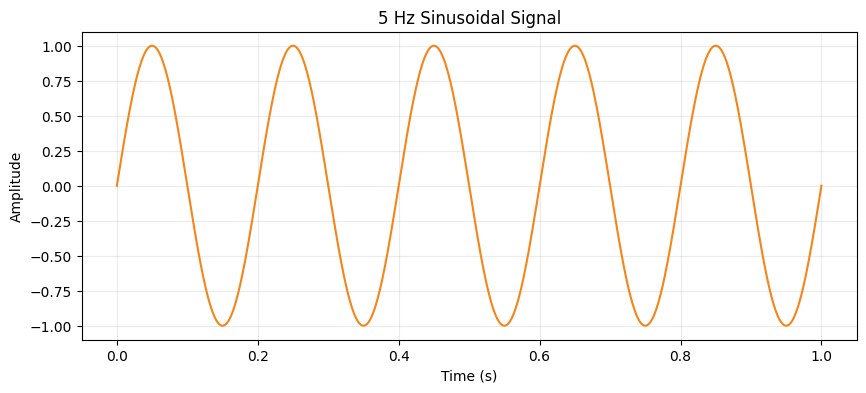

Average power of the 5 Hz (1 W) sinusoidal signal: 0.5 Watts


In [33]:
# Sinusoidal signal
t = np.linspace(0, 1, 1000)  # Time vector from
# 0 to 1 second with 1000 samples
f = 5  # Frequency of the sinusoid in Hz
A = 1  # Amplitude of the sinusoid in Watts
sin_signal = A * np.sin(2 * np.pi * f * t)

plt.figure(figsize=(10, 4))
plt.plot(t, sin_signal, color="#F58518")
plt.title("5 Hz Sinusoidal Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.25)
plt.show()

average_power_sin = A/2
print(f"Average power of the 5 Hz (1 W) sinusoidal signal: {average_power_sin:.1f} Watts")
